In [1]:
from langgraph.graph import StateGraph, START , END
from typing import TypedDict , Annotated
from langchain_core.messages import BaseMessage , HumanMessage
from langchain_groq import  ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv()

True

In [3]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage] , add_messages]

In [4]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.7
)

In [5]:
def chat_node(state: ChatState):
    #take user from state
    messages = state['messages']

    #send to llm
    result = model.invoke(messages)

    #store in state again
    return {'messages': [result]}


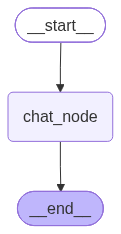

In [6]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

#add nodes

graph.add_node('chat_node', chat_node)


graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)
chatbot



In [7]:
thread_id = '1'
while True:
    user_message = input('Enter your query')

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    config = {'configurable': {'thread_id': thread_id}}
    response =  chatbot.invoke({'messages': [HumanMessage(content= user_message)]}, config=config)
    print("AI : ", response["messages"][-1].content)

AI :  Hello Trishna! 👋 How can I help you today?
AI :  Got it! If you need anything else later, just let me know. Have a great day!


In [8]:
initial_state = {'messages':[HumanMessage (content= 'What are best places to visit in pune?') ]}

result = chatbot.invoke(initial_state)

print(result["messages"][-1].content)


ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
result

{'messages': [HumanMessage(content='What are best places to visit in pune?', additional_kwargs={}, response_metadata={}, id='9c683de8-f69c-4b66-90e8-f6a2eab67520'),
  AIMessage(content='### Top Places to Visit in Pune (and a Few Nearby Gems)\n\n| # | Attraction | Type | Why It’s Worth a Stop | Tips & Best Times |\n|---|------------|------|----------------------|-------------------|\n| 1 | **Shaniwar Wada** | Historical fort | Iconic 18th‑century Maratha palace with dramatic architecture and a haunting history. | Visit early morning to avoid crowds; catch the **light‑and‑sound show** (Mon‑Fri, 7\u202fpm). |\n| 2 | **Aga Khan Palace** | Historical / Memorial | A beautiful neo‑Mughal palace where Gandhi and his wife were interned during the freedom struggle. | Bring a camera—gardens and marble arches are photogenic. |\n| 3 | **Raja Dinkar Kelkar Museum** | Museum / Art | Over 20,000 artifacts ranging from musical instruments to everyday objects of yesteryear. | Guided tours are free; spen